# 扇入

前面讲了扇出，现在讲讲扇入
扇入就是分发的多个任务合并起来
扇入又划分成静态扇入和动态扇入， 和静态分支和动态分支前面学的对应起来

静态: 合并到一起的时候，可能有与也可能有或，另外一种，
动态: 可以扇出fan-out，给下游发多个数据，多个任务，动态合并

先一个个展示，先静态扇入

与触发： 都运行完，自己再运行
或触发：某一个运行完，下一个触发

只有一种情况没有区别，A和B的都是超步2执行的，到C没有区别
但如果左边ABD， 右边CD， 有区别那个超步阶段与和或有区别

想要查询superstep可以读取
```
config["metadata"]["langgraph_step"]
```
编号是执行超步的编号，可以获取到里面的，就可以直观的看到与触发和或触发

2026-09-09 18:44:15.804 | INFO     | __main__:node_a:17 - 当前步骤： 1
2026-09-09 18:44:15.806 | INFO     | __main__:node_b:22 - 当前步骤： 2
2026-09-09 18:44:15.809 | INFO     | __main__:node_c:27 - 当前步骤： 2
2026-09-09 18:44:15.810 | INFO     | __main__:node_d:32 - 当前步骤： 3
2026-09-09 18:44:15.811 | INFO     | __main__:node_e:37 - 当前步骤： 3
2026-09-09 18:44:15.813 | INFO     | __main__:node_e:37 - 当前步骤： 4


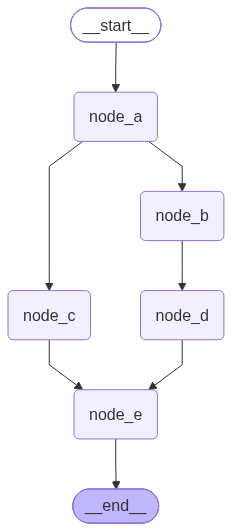

In [2]:
from typing import TypedDict

from langgraph import graph
from loguru import logger

from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, END, START

# 先与触发
# 1. 定义状态
class EmptyState(TypedDict):
    pass

# 2. 声明节点
def node_a(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤： {cur_step}")
    return state

def node_b(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤： {cur_step}")
    return state

def node_c(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤： {cur_step}")
    return state

def node_d(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤： {cur_step}")
    return state

def node_e(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤： {cur_step}")
    return state


# 3. 构建图
builder = StateGraph(state_schema=EmptyState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_node("node_d", node_d)
builder.add_node("node_e", node_e)

builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_a", "node_c")
builder.add_edge("node_b", "node_d")

# 或节点扇入关系
builder.add_edge("node_c", "node_e") # 这里是或，c或者d执行玩就执行e
# ！！！！！！！！！e节点执行两次！！！！！！！！！！！！！
builder.add_edge("node_d", "node_e")

builder.add_edge("node_e", END)

graph = builder.compile()
graph.invoke({})

from IPython.display import display
display(graph)

# 说明a执行一步， bc同时一起， de同时一起， e最后一步执行


2026-09-09 18:48:04.092 | INFO     | __main__:node_a:17 - 当前步骤： 1
2026-09-09 18:48:04.094 | INFO     | __main__:node_b:22 - 当前步骤： 2
2026-09-09 18:48:04.097 | INFO     | __main__:node_c:27 - 当前步骤： 2
2026-09-09 18:48:04.101 | INFO     | __main__:node_d:32 - 当前步骤： 3
2026-09-09 18:48:04.102 | INFO     | __main__:node_e:37 - 当前步骤： 4


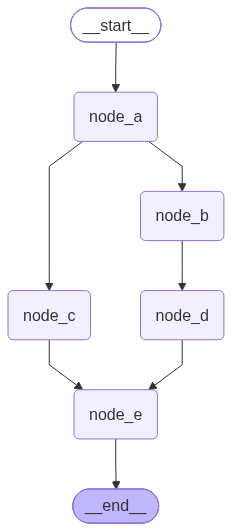

In [4]:
from typing import TypedDict

from langgraph import graph
from loguru import logger

from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, END, START

# 先与触发
# 1. 定义状态
class EmptyState(TypedDict):
    pass

# 2. 声明节点
def node_a(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤： {cur_step}")
    return state

def node_b(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤： {cur_step}")
    return state

def node_c(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤： {cur_step}")
    return state

def node_d(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤： {cur_step}")
    return state

def node_e(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤： {cur_step}")
    return state


# 3. 构建图
builder = StateGraph(state_schema=EmptyState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_node("node_d", node_d)
builder.add_node("node_e", node_e)

builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_a", "node_c")
builder.add_edge("node_b", "node_d")

# 与节点扇入关系
builder.add_edge(["node_c", "node_d"], "node_e") #  与， c和d同时执行完才能执行b
builder.add_edge("node_e", END)

graph = builder.compile()
graph.invoke({})

from IPython.display import display
display(graph)

# 说明a执行一步， bc同时一起， de同时一起， e最后一步执行


# 问题一

2026-09-09 18:44:15.804 | INFO     | __main__:node_a:17 - 当前步骤： 1
2026-09-09 18:44:15.806 | INFO     | __main__:node_b:22 - 当前步骤： 2
2026-09-09 18:44:15.809 | INFO     | __main__:node_c:27 - 当前步骤： 2
2026-09-09 18:44:15.810 | INFO     | __main__:node_d:32 - 当前步骤： 3
2026-09-09 18:44:15.811 | INFO     | __main__:node_e:37 - 当前步骤： 3
2026-09-09 18:44:15.813 | INFO     | __main__:node_e:37 - 当前步骤： 4
2026-09-09 18:48:04.092 | INFO     | __main__:node_a:17 - 当前步骤： 1
2026-09-09 18:48:04.094 | INFO     | __main__:node_b:22 - 当前步骤： 2
2026-09-09 18:48:04.097 | INFO     | __main__:node_c:27 - 当前步骤： 2
2026-09-09 18:48:04.101 | INFO     | __main__:node_d:32 - 当前步骤： 3
2026-09-09 18:48:04.102 | INFO     | __main__:node_e:37 - 当前步骤： 4
我有点不理解为什么上面是或，下面是与，  超步supterstep怎么看？

# 回答一

好问题！让我先看清楚你的代码结构，再详细解释超步和扇入/扇出的关系。

## 你的图结构

```
START -> node_a -> node_b -> node_d ─┐
                └-> node_c ---------> node_e -> END
                                         ↑
                              node_d ----┘
```

**关键边：**
- `node_a -> node_b` 和 `node_a -> node_c`（**扇出**：一个节点分叉到多个）
- `node_c -> node_e` 和 `node_d -> node_e`（**OR 扇入**：两条独立边指向同一个节点）
- 注释掉的 `# builder.add_edge(["node_c","node_d"],"node_e")`（**AND 扇入**：等待所有前驱都完成）

---

## 超步（Superstep）是什么？

**超步**是 LangGraph 中一次"执行波次"。在每个超步中，LangGraph 会：
1. 找出所有**前驱节点都已执行完毕**的"就绪"节点
2. **并行执行**所有就绪节点
3. 收集结果，进入下一个超步

`config["metadata"]["langgraph_step"]` 记录的就是**当前所在的超步编号**。

---

## 你的两次运行结果对比

### 第一次运行（OR 扇入行为）

| 超步 | 执行的节点 | 触发原因 |
|:---:|:----------|:---------|
| **1** | `node_a` | START 触发 |
| **2** | `node_b`, `node_c` | 两者都被 `node_a` 扇出触发，并行执行 |
| **3** | `node_d`, `node_e` | `node_d` 被 `node_b` 触发；**`node_e` 被 `node_c` 触发** |
| **4** | `node_e` | **`node_e` 又被 `node_d` 触发** |

**`node_e` 运行了 2 次**，因为 OR 扇入下，两条独立边 `node_c -> node_e` 和 `node_d -> node_e` 各自独立触发。

### 第二次运行（看起来像 AND 扇入行为）

| 超步 | 执行的节点 | 触发原因 |
|:---:|:----------|:---------|
| **1** | `node_a` | START 触发 |
| **2** | `node_b`, `node_c` | 扇出并行 |
| **3** | `node_d` | 被 `node_b` 触发 |
| **4** | `node_e` | 被 `node_c` 和 `node_d` **共同**触发（去重后只执行一次） |

**`node_e` 只运行了 1 次**。

---

## 为什么两次运行结果不同？

这是因为 **OR 扇入的非确定性（non-deterministic）** 行为：

### OR 扇入（你当前代码）：
```python
builder.add_edge("node_c", "node_e")  # 独立边1
builder.add_edge("node_d", "node_e")  # 独立边2
```

- `node_e` 有两条独立入边，每条边都可以单独触发它
- **如果两条触发发生在不同超步** → `node_e` 运行 2 次（第一次运行）
- **如果两条触发在进入下一超步前合并了** → `node_e` 运行 1 次（第二次运行）
- 这种不确定性取决于 `node_c` 和 `node_d` 的执行完成时间

### AND 扇入（被注释掉的代码）：
```python
# builder.add_edge(["node_c", "node_d"], "node_e")
```

- `node_e` 只有一条入边，但要求**两个前驱都完成**才触发
- `node_c` 在超步 2 完成 → `node_e` 还不能运行（等 `node_d`）
- `node_d` 在超步 3 完成 → 两个都完成了 → `node_e` 在超步 4 运行
- **确定性行为：`node_e` 始终只运行 1 次**

---

## 总结：超步怎么看？

```
超步 1:  [node_a]                    ← 起始节点
超步 2:  [node_b, node_c]            ← 扇出，并行执行
超步 3:  [node_d, node_e(OR)]        ← OR 扇入可能在这里触发
超步 4:  [node_e(OR 再次)]            ← OR 扇入可能再次触发
```

**核心口诀：**
- **扇出（Fan-out）**：一个节点 → 多个节点，**同超步**并行（如超步 2 的 `node_b` 和 `node_c`）
- **OR 扇入**：多条独立边 → 同一个节点，可能**触发多次**，**不同超步**
- **AND 扇入**：多条边合并为一条 → 同一个节点，**只触发一次**，在所有前驱完成后的**下一个超步**

如果你想消除不确定性，让 `node_e` 始终只运行一次，就把注释掉的 AND 扇入打开，把两条独立边注释掉：

```python
# 或节点扇入关系（OR）- 非确定性，可能触发多次
# builder.add_edge("node_c", "node_e")
# builder.add_edge("node_d", "node_e")

# 与节点扇入关系（AND）- 确定性，始终触发一次
builder.add_edge(["node_c", "node_d"], "node_e")
```

这样 `node_e` 就一定会在超步 4 只执行一次了。

# 问题二
```text
node_e 有两条独立入边，每条边都可以单独触发它
 如果两条触发发生在不同超步 → node_e 运行 2 次（第一次运行）
 如果两条触发在进入下一超步前合并了 → node_e 运行 1 次（第二次运行）
 这种不确定性取决于 node_c 和 node_d 的执行完成时间

我不理解你说的不确定性，  难道不是按照下面的书顺序
 1 	 node_a 	 START 触发
 2 	 node_b, node_c 	 两者都被 node_a 扇出触发，并行执行
 3 	 node_d, node_e 	 node_d 被 node_b 触发；node_e 被 node_c 触发
 4 	 node_e 	 node_e 又被 node_d 触发

或者
 2026-06-05 15:09:11.715 | INFO     | __main__:node_a:12 - cur_step: 1, node_a 被触发
 2026-06-05 15:09:11.720 | INFO     | __main__:node_b:17 - cur_step: 2, node_b 被触发
 2026-06-05 15:09:11.723 | INFO     | __main__:node_c:22 - cur_step: 2, node_c 被触发
 2026-06-05 15:09:11.729 | INFO     | __main__:node_d:27 - cur_step: 3, node_d 被触发
 2026-06-05 15:09:11.729 | INFO     | __main__:node_e:32 - cur_step: 3, node_e 被触发
 2026-06-05 15:09:11.732 | INFO     | __main__:node_e:32 - cur_step: 4, node_e 被触发

一定超步1 -》 超步2 -》 超步3 -》 超步4， 导致node_e一定被执行两次吗？ 请给我严谨的回答， 有了随机性什么意思？
```

# 回答二
你说得对，我之前说的"非确定性"是错误的，**在这个图结构下，执行是完全确定的**。让我给出严谨的分析。

---

## 严谨的超步分析

你的图结构（OR 扇入，两条独立边）：

```
START -> node_a -> node_b -> node_d ─┐
                └-> node_c ---------> node_e -> END
                                         ↑
                              node_d ----┘
```

**依赖链分析：**

| 节点 | 依赖哪些节点 | 最早可在哪个超步执行 |
|:----:|:------------|:-----------------:|
| `node_a` | 无（START） | 超步 1 |
| `node_b` | `node_a` | 超步 2 |
| `node_c` | `node_a` | 超步 2 |
| `node_d` | `node_b` | 超步 3 |
| `node_e` | `node_c` **或** `node_d` | 超步 3（由 `node_c` 触发） |
| `node_e`（再次） | `node_d` | 超步 4（由 `node_d` 触发） |

**超步执行的确定性推演：**

| 超步 | 执行的节点 | 执行后触发的新就绪节点 |
|:---:|:----------|:---------------------|
| **1** | `node_a` | `node_b` ✅, `node_c` ✅ |
| **2** | `node_b`, `node_c`（并行） | `node_d` ✅（由 `node_b` 触发）, `node_e` ✅（由 `node_c` 触发） |
| **3** | `node_d`, `node_e`（并行） | `node_e` ✅（由 `node_d` 触发） |
| **4** | `node_e` | 无 → END |

**结论：`node_e` 一定、必然、确定地在超步 3 和超步 4 各执行一次，共 2 次。没有任何随机性。**

---

## 为什么我之前说"非确定性"是错误的

我之前的解释有误。让我纠正：

**OR 扇入（独立边）的确定性规则：**
```
每个前驱节点完成时，独立触发一次下游节点。
由于 node_c 在超步 2 完成，node_d 在超步 3 完成，
这两个触发必然发生在不同超步，
因此 node_e 必然被触发两次。
```

**不存在"两条触发在进入下一超步前合并"的情况**，因为：
- `node_d` 依赖 `node_b`，而 `node_b` 在超步 2 执行
- `node_d` 最早只能在 **超步 3** 执行
- `node_c` 在超步 2 完成时，`node_d` 还没开始执行，更不可能完成
- 所以 `node_c` 和 `node_d` 的完成**必然跨越两个不同的超步**

---

## 你的第二次运行为什么只有超步 4 的 `node_e`？

让我再仔细看你的第二次输出：

```
node_a: 当前步骤： 1
node_b: 当前步骤： 2
node_c: 当前步骤： 2
node_d: 当前步骤： 3
node_e: 当前步骤： 4
```

**只有 5 条日志，缺少了超步 3 的 `node_e`**。

出现这种情况的唯一可能是——**你第二次运行的代码和图不一样**，大概率是切换到了 **AND 扇入**：

```python
# 或节点扇入关系（被注释掉了）
# builder.add_edge("node_c", "node_e")
# builder.add_edge("node_d", "node_e")

# 与节点扇入关系（生效了）
builder.add_edge(["node_c", "node_d"], "node_e")
```

AND 扇入的推演：

| 超步 | 执行的节点 | 说明 |
|:---:|:----------|:-----|
| 1 | `node_a` | START 触发 |
| 2 | `node_b`, `node_c` | `node_c` 完成，但 `node_e` **等待 `node_d`** |
| 3 | `node_d` | `node_d` 完成，**两个前驱都完成了**，`node_e` 就绪 |
| 4 | `node_e` | 执行一次，结束 |

---

## 总结

| 扇入方式 | 代码 | `node_e` 执行次数 | 确定性 |
|:--------|:-----|:----------------:|:-------:|
| **OR 扇入** | `add_edge("node_c","node_e")` + `add_edge("node_d","node_e")` | **2 次**（超步 3 + 超步 4） | ✅ **完全确定** |
| **AND 扇入** | `add_edge(["node_c","node_d"],"node_e")` | **1 次**（超步 4） | ✅ **完全确定** |

**没有随机性，没有不确定性。** 在这个 DAG 结构中，执行顺序完全由依赖关系决定，每次运行结果都是一致的。你第二次运行看到的不同结果，一定是因为代码被修改成了 AND 扇入。